# Week 4 — power and sample size

**27200 Data-driven Bioengineering · group assignment 3**

Everything the assignment needs, in one notebook. **Run the setup cell, then jump to the section for
your case** — the sections are independent and each one is a worked example you can retarget by
changing the numbers at the top.

| Section | Use it for | Case |
|---|---|---|
| 1 | Two groups, one measurement each | 1 |
| 2 | Repeated measurements of the same unit — which n? | 2, 6 |
| 3 | Two proportions (yes/no outcomes) | 3 |
| 4 | Thousands of tests at once | 4 |
| 5 | Paired designs — everyone measured under every condition | 5 |
| 6 | More than two groups, and what to do when the data are not normal | 6 |
| 7 | **Simulation** — when there is no formula | any |

> **The four quantities.**
> Power calculations connect four things: the **effect size** (how big a difference, relative to the
> noise), the **sample size**, the **significance level** α, and the **power** (the chance of
> detecting a real effect). **Fix any three and the fourth is determined.** Every function below does
> exactly this — leave out the one you want and it solves for it.
>
> By convention: α = 0.05, power = 0.80. Power 0.80 means that if the effect is really there at the
> size you assumed, you will miss it one time in five.

---
## 0 · Setup

Run this once.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower, TTestPower, FTestAnovaPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.multitest import multipletests

rng = np.random.default_rng(27200)      # reproducible random numbers
tt_ind  = TTestIndPower()               # two independent groups
tt_pair = TTestPower()                  # paired / one sample
anova   = FTestAnovaPower()             # more than two groups
print("ready")

ready


---
## 1 · Two groups, one measurement each

The standard two-sample t-test design. You need two numbers: the **smallest difference worth
detecting** and the **standard deviation** of the measurement. Their ratio is Cohen's *d* — the
difference expressed in units of noise, which is the only thing the calculation cares about.

The numbers below are Case 1's; replace them with your own.

In [2]:
delta = 10.0        # smallest difference that matters, in the units you measure (percentage points)
sd    = 18.0        # standard deviation of the measurement, from pilot data or the literature
d     = delta / sd  # Cohen's d: the difference, measured in standard deviations

n = tt_ind.solve_power(effect_size=d, power=0.80, alpha=0.05)

print(f"effect size d      = {d:.3f}")
print(f"n needed per group = {np.ceil(n):.0f}   (so {2*np.ceil(n):.0f} in total)")

effect size d      = 0.556
n needed per group = 52   (so 104 in total)


### Leaving out a different quantity

Same function, different blank. This is how you answer "what can I detect with the patients I
actually have?" — the question the constraint in your case will force you to ask.

In [3]:
n_available = 40    # what you can realistically recruit per group

# (a) how much power do I have with the n I can get?
power_have = tt_ind.solve_power(effect_size=d, nobs1=n_available, alpha=0.05)

# (b) what is the smallest difference I could detect with that n, at 80% power?
d_detect = tt_ind.solve_power(nobs1=n_available, power=0.80, alpha=0.05)

print(f"with n = {n_available} per group: power = {power_have:.2f}")
print(f"smallest detectable difference    = {d_detect*sd:.1f} units  (d = {d_detect:.2f})")

with n = 40 per group: power = 0.69
smallest detectable difference    = 11.4 units  (d = 0.63)


### Dropout

Sample size calculations give you the number of people who must **finish**. Inflate for the ones who
will not.

In [4]:
dropout = 0.15                          # fraction expected to drop out
n_enrol = np.ceil(n) / (1 - dropout)
print(f"must complete: {np.ceil(n):.0f} per group")
print(f"must enrol:    {np.ceil(n_enrol):.0f} per group  ({2*np.ceil(n_enrol):.0f} total)")

must complete: 52 per group
must enrol:    62 per group  (124 total)


### The power curve

The single most useful figure for this assignment: power against sample size, with your constraint
drawn on it. It makes the trade-off visible in a way a sentence cannot.

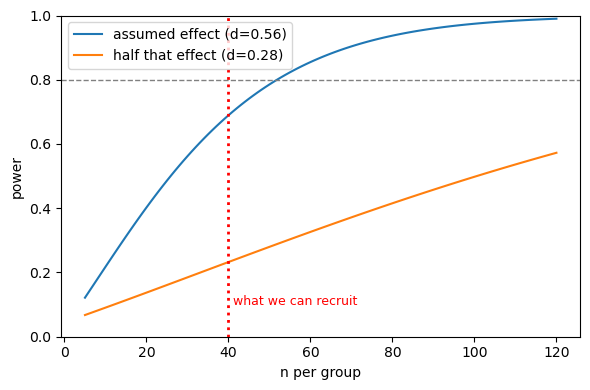

In [5]:
ns = np.arange(5, 121)
plt.figure(figsize=(6, 4))
for dd, lab in [(d, f"assumed effect (d={d:.2f})"), (d/2, f"half that effect (d={d/2:.2f})")]:
    plt.plot(ns, tt_ind.solve_power(effect_size=dd, nobs1=ns, alpha=0.05), label=lab)
plt.axhline(0.80, ls="--", c="grey", lw=1)                      # the 80% convention
plt.axvline(n_available, ls=":", c="red", lw=2)                 # what you can actually get
plt.text(n_available+1, 0.1, "what we can recruit", color="red", fontsize=9)
plt.xlabel("n per group"); plt.ylabel("power"); plt.ylim(0, 1)
plt.legend(); plt.tight_layout(); plt.show()

---
## 2 · Repeated measurements of the same unit

**This is the one that catches people.** If you culture three bioreactors and take ten samples from
each, you have thirty measurements but you do **not** have n = 30. You have n = 3. The ten samples
tell you how precisely you measured *that reactor*, not how much reactors differ from each other —
and it is the second question your experiment is asking.

The rule: **n is the number of independent units you could have replaced with a different one.**
Different reactor run, different animal, different patient, different overnight culture. Repeated
measurements of one unit are called *technical replicates*, and they belong inside the unit's mean.

Below: what those extra samples actually buy you.

In [6]:
sd_between = 0.35   # SD between independent units (different runs of the same process)
sd_within  = 0.12   # SD between repeated measurements of ONE unit (assay noise)
delta      = 0.5    # smallest difference worth detecting

for k in [1, 2, 5, 10, 50]:
    # the SE of one unit's mean: unit-to-unit variation, plus assay noise divided by k
    se = np.sqrt(sd_between**2 + sd_within**2 / k)
    n  = tt_ind.solve_power(effect_size=delta/se, power=0.80, alpha=0.05)
    print(f"{k:3d} measurements per unit -> effective SD {se:.3f} -> {np.ceil(n):3.0f} UNITS per group")

print()
n_wrong = tt_ind.solve_power(effect_size=delta/sd_within, power=0.80, alpha=0.05)
print(f"If you wrongly treat each measurement as independent: {np.ceil(n_wrong):.0f} 'samples' per group.")
print("That is the error. It makes an underpowered experiment look comfortably powered.")

  1 measurements per unit -> effective SD 0.370 ->  10 UNITS per group
  2 measurements per unit -> effective SD 0.360 ->  10 UNITS per group
  5 measurements per unit -> effective SD 0.354 ->   9 UNITS per group
 10 measurements per unit -> effective SD 0.352 ->   9 UNITS per group
 50 measurements per unit -> effective SD 0.350 ->   9 UNITS per group

If you wrongly treat each measurement as independent: 3 'samples' per group.
That is the error. It makes an underpowered experiment look comfortably powered.


Notice how flat that list is. Once the unit-to-unit variation dominates, extra measurements of the
same unit are almost free of benefit — the money belongs in **more units**, not more samples per
unit. Quote that comparison in your report; it is a design decision with a number attached.

---
## 3 · Two proportions

When the outcome is yes/no rather than a measurement, there is no standard deviation — the
variability is set by the rate itself. The effect size is Cohen's *h*, which statsmodels computes
from the two proportions for you.

In [7]:
p_control = 0.02    # baseline rate
p_exposed = 0.03    # the rate you want to be able to detect (here: a 50% increase)

h = proportion_effectsize(p_exposed, p_control)
n = tt_ind.solve_power(effect_size=h, power=0.80, alpha=0.05)
print(f"effect size h = {h:.4f}")
print(f"n per group   = {np.ceil(n):.0f}")

# Rare outcomes are expensive: the same relative increase costs far more at a low baseline rate.
print()
for p0, p1 in [(0.02, 0.03), (0.02, 0.04), (0.20, 0.30)]:
    nn = tt_ind.solve_power(effect_size=proportion_effectsize(p1, p0), power=0.80, alpha=0.05)
    print(f"  {p0:.0%} -> {p1:.0%}: {np.ceil(nn):6.0f} per group")

effect size h = 0.0644
n per group   = 3790

  2% -> 3%:   3790 per group
  2% -> 4%:   1111 per group
  20% -> 30%:    293 per group


### Unequal group sizes

Registry and cohort studies rarely have equal groups. `ratio` is the size of the second group as a
multiple of the first. Note how the benefit saturates: past about 4 or 5 controls per case, extra
controls buy you almost nothing, and the smaller group is what limits you.

In [8]:
h = proportion_effectsize(0.03, 0.02)
for ratio in [1, 2, 4, 8, 32]:
    n1 = tt_ind.solve_power(effect_size=h, power=0.80, alpha=0.05, ratio=ratio)
    print(f"  {ratio:2d} unexposed per exposed: {np.ceil(n1):6.0f} exposed needed")

print()
n_have = 1200
print(f"power with {n_have} exposed at 32:1 -> {tt_ind.solve_power(effect_size=h, nobs1=n_have, alpha=0.05, ratio=32):.2f}")

   1 unexposed per exposed:   3790 exposed needed
   2 unexposed per exposed:   2842 exposed needed
   4 unexposed per exposed:   2369 exposed needed
   8 unexposed per exposed:   2132 exposed needed
  32 unexposed per exposed:   1954 exposed needed

power with 1200 exposed at 32:1 -> 0.59


---
## 4 · Thousands of tests at once

Test 20,000 genes at α = 0.05 and roughly 1,000 will come out significant with nothing going on.
Correcting for that makes the threshold much stricter — and a stricter threshold needs a **bigger
sample** to clear. This is the cost of a genome-scale screen, and it is usually the reason such
screens are underpowered.

First, what the correction does to the sample size you need:

In [9]:
n_tests = 20000
d = 1.0 / 0.5      # log2 fold change of 1, replicate SD of 0.5 on the log2 scale

for alpha, label in [(0.05, "no correction"), (0.05/n_tests, "Bonferroni")]:
    n = tt_ind.solve_power(effect_size=d, power=0.80, alpha=alpha)
    print(f"{label:>14}: alpha = {alpha:.2e} -> n = {np.ceil(n):.0f} per group")

print()
for n_have in [4, 6, 10, 21]:
    p = tt_ind.solve_power(effect_size=d, nobs1=n_have, alpha=0.05/n_tests)
    print(f"  power at n = {n_have:2d} per group (Bonferroni): {p:.3f}")

 no correction: alpha = 5.00e-02 -> n = 6 per group
    Bonferroni: alpha = 2.50e-06 -> n = 21 per group

  power at n =  4 per group (Bonferroni): 0.000
  power at n =  6 per group (Bonferroni): 0.003
  power at n = 10 per group (Bonferroni): 0.070
  power at n = 21 per group (Bonferroni): 0.810


Bonferroni is the strict end. Benjamini–Hochberg (FDR) is what genomics actually uses, and it has
no simple formula — so simulate it. The loop below builds a whole experiment: 20,000 genes, a few
hundred genuinely changed, and counts how many of them survive FDR correction.

In [10]:
def fdr_power(n_per_group, n_tests=20000, n_true=200, log2fc=1.0, sd=0.5, reps=20):
    '''Fraction of genuinely changed genes recovered at FDR < 0.05.'''
    found, false = [], []
    for _ in range(reps):
        a = rng.normal(0, sd, (n_tests, n_per_group))
        b = rng.normal(0, sd, (n_tests, n_per_group))
        b[:n_true] += log2fc                                   # the genes that really changed
        p = stats.ttest_ind(a, b, axis=1).pvalue
        sig = multipletests(p, alpha=0.05, method="fdr_bh")[0]
        found.append(sig[:n_true].sum() / n_true)
        false.append(sig[n_true:].sum())
    return np.mean(found), np.mean(false)

for n in [3, 4, 6, 10, 15]:
    frac, fp = fdr_power(n)
    print(f"n = {n:2d} per group: {frac:5.1%} of real changes found, {fp:5.1f} false positives")

n =  3 per group:  0.0% of real changes found,   0.1 false positives


n =  4 per group:  0.1% of real changes found,   0.0 false positives
n =  6 per group:  1.2% of real changes found,   0.3 false positives


n = 10 per group: 50.7% of real changes found,   5.2 false positives
n = 15 per group: 91.0% of real changes found,   9.3 false positives


---
## 5 · Paired designs

If the same subject is measured under both conditions, each subject is their own control, and the
comparison is made *within* subjects. The standard deviation that matters is the **within-subject**
one, which is nearly always much smaller than the between-subject one. That is why crossover designs
need so many fewer people.

Use `tt_pair` (not `tt_ind`), and note that `nobs` here is the number of **subjects**, not the
number of measurements.

In [11]:
delta      = 40.0     # smallest meaningful difference between two conditions
sd_within  = 45.0     # same person, same condition, different day
sd_between = 90.0     # different people

n_paired = tt_pair.solve_power(effect_size=delta/sd_within, power=0.80, alpha=0.05)
sd_total = np.sqrt(sd_between**2 + sd_within**2)
n_parallel = tt_ind.solve_power(effect_size=delta/sd_total, power=0.80, alpha=0.05)

print(f"paired  (everyone does both): {np.ceil(n_paired):4.0f} subjects in total")
print(f"parallel (two separate groups): {np.ceil(n_parallel):4.0f} per group, {2*np.ceil(n_parallel):.0f} in total")
print(f"\npairing saves a factor of {2*np.ceil(n_parallel)/np.ceil(n_paired):.0f} in people.")

paired  (everyone does both):   12 subjects in total
parallel (two separate groups):  101 per group, 202 in total

pairing saves a factor of 17 in people.


### Several conditions means several comparisons

With five conditions there are 10 pairwise comparisons, so the threshold tightens and n goes up.
Decide *in advance* whether you need all the pairs, or only each condition against a reference —
that choice alone changes the number of people you must recruit.

In [12]:
from itertools import combinations
k = 5
n_all_pairs   = len(list(combinations(range(k), 2)))     # every meal against every other
n_vs_control  = k - 1                                    # every meal against one reference

for label, m in [("no correction", 1), (f"all {n_all_pairs} pairs", n_all_pairs),
                 (f"{n_vs_control} vs a reference", n_vs_control)]:
    n = tt_pair.solve_power(effect_size=delta/sd_within, power=0.80, alpha=0.05/m)
    print(f"{label:>22}: alpha = {0.05/m:.4f} -> {np.ceil(n):3.0f} subjects")

         no correction: alpha = 0.0500 ->  12 subjects
          all 10 pairs: alpha = 0.0050 ->  21 subjects
      4 vs a reference: alpha = 0.0125 ->  18 subjects


---
## 6 · More than two groups, and non-normal data

For an overall "do these k groups differ at all?" test — one-way ANOVA — the effect size is
Cohen's *f*. As a rough guide, *f* ≈ *d* / 2 when you are thinking of the difference between the
two most extreme groups.

**Watch out:** statsmodels returns the **total** sample size here, not the size per group.

In [13]:
group_means = np.array([0, 1.0, 2.0, 3.0, 4.0])   # expected mean per dose (log10 CFU below control)
sd_within   = 0.9                                 # SD between independent biological repeats
k = len(group_means)

# Cohen's f: the spread of the group means, in units of the within-group SD
f = np.sqrt(((group_means - group_means.mean())**2).mean()) / sd_within
n_total = anova.solve_power(effect_size=f, k_groups=k, power=0.80, alpha=0.05)

print(f"Cohen's f  = {f:.2f}")
print(f"ANOVA: total n = {np.ceil(n_total):.0f}  ->  {np.ceil(n_total/k):.0f} per group")

Cohen's f  = 1.57
ANOVA: total n = 11  ->  3 per group


**But the omnibus test is rarely the question you care about.** "Do these five doses differ at
all?" is easy to answer. "Which is the lowest dose that still works?" is a set of pairwise
comparisons between neighbouring doses — a much smaller difference, tested several times, so
corrected — and *that* is what should set your sample size.

Design for the comparison you actually want to make, not for the omnibus test.

In [14]:
delta_adjacent = 1.0                      # difference between two neighbouring doses
d = delta_adjacent / sd_within
m = k - 1                                 # comparisons against the control

print(f"omnibus ANOVA:                        {np.ceil(n_total/k):3.0f} per group")
print(f"one pairwise comparison, uncorrected: {np.ceil(tt_ind.solve_power(effect_size=d, power=0.80, alpha=0.05)):3.0f} per group")
print(f"{m} comparisons, Bonferroni:            {np.ceil(tt_ind.solve_power(effect_size=d, power=0.80, alpha=0.05/m)):3.0f} per group")

omnibus ANOVA:                          3 per group
one pairwise comparison, uncorrected:  14 per group
4 comparisons, Bonferroni:             20 per group


### When the data are not normal

An ANOVA or a t-test assumes roughly normal residuals and similar spread in each group. **Check
before you trust them**, and write down in advance what you will do if the check fails.

Three outcomes, three different responses:

- **Skewed but continuous** (counts, concentrations, CFU/mL) — take logs first. A log-normal
  quantity becomes normal, and a "fold change" becomes a difference, which is what the test compares.
- **Still not normal after transforming, or ordinal** — use a rank-based test: Mann–Whitney/Wilcoxon
  instead of a t-test, Kruskal–Wallis instead of ANOVA, with Dunn's test for the follow-up pairs.
  These compare ranks, so they do not care about the shape.
- **Censored values** — measurements reported as "below the detection limit" are not numbers, and no
  transformation makes them into numbers. Rank-based tests handle them (ties at the bottom); means
  and t-tests do not.

The cell below shows the check on simulated skewed data, and the price of going non-parametric.

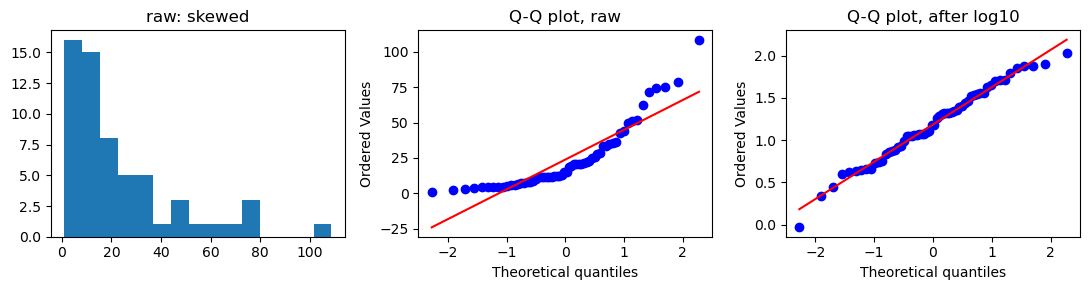

Shapiro-Wilk, raw:      p = 2.87e-07
Shapiro-Wilk, log10(x): p = 0.685


In [15]:
# some deliberately skewed data, the way a CFU/mL count behaves
x = rng.lognormal(mean=3, sigma=1.0, size=60)

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].hist(x, bins=15); ax[0].set_title("raw: skewed")
stats.probplot(x, plot=ax[1]); ax[1].set_title("Q-Q plot, raw")
stats.probplot(np.log10(x), plot=ax[2]); ax[2].set_title("Q-Q plot, after log10")
plt.tight_layout(); plt.show()

# Shapiro-Wilk: small p = evidence AGAINST normality
print(f"Shapiro-Wilk, raw:      p = {stats.shapiro(x).pvalue:.2e}")
print(f"Shapiro-Wilk, log10(x): p = {stats.shapiro(np.log10(x)).pvalue:.3f}")

**How much does a rank-based test cost you?** Less than people fear. When the data really are
normal, Mann–Whitney needs about 5% more samples than a t-test. When they are not, it often needs
fewer. Simulate it for your own design rather than guessing:

In [16]:
def power_sim(n, delta, sd, test, reps=2000):
    '''Fraction of simulated experiments in which the test reaches p < 0.05.'''
    hits = 0
    for _ in range(reps):
        a = rng.normal(0,     sd, n)
        b = rng.normal(delta, sd, n)
        p = (stats.ttest_ind(a, b).pvalue if test == "t"
             else stats.mannwhitneyu(a, b).pvalue)
        hits += p < 0.05
    return hits / reps

for n in [10, 15, 20]:
    t  = power_sim(n, 1.0, 0.9, "t")
    mw = power_sim(n, 1.0, 0.9, "mannwhitney")
    print(f"n = {n:2d} per group:  t-test {t:.2f}   Mann-Whitney {mw:.2f}")

n = 10 per group:  t-test 0.64   Mann-Whitney 0.59


n = 15 per group:  t-test 0.85   Mann-Whitney 0.79


n = 20 per group:  t-test 0.92   Mann-Whitney 0.92


## 7 · When there is no formula: simulate

Formulas exist for the common designs. For anything else — a non-parametric test, a nested design,
a weird outcome distribution, censored values — there is no formula, and you do not need one.

**Power is just "how often would this experiment work?"** So build the experiment in code, run it a
thousand times with the effect you hope to find, and count how often the test comes out significant.
That fraction is the power. It is slower than a formula and correct for every design.

The template below can be bent to any of the six cases: change how the data are made, change the
test, keep the loop.

In [17]:
def simulate_power(n, reps=2000):
    '''EDIT THE TWO MARKED LINES. Everything else stays the same.'''
    hits = 0
    for _ in range(reps):
        # 1. build one fake experiment, with the effect you hope is there ------------
        group_a = rng.normal(50, 18, n)
        group_b = rng.normal(60, 18, n)
        # 2. run exactly the test you plan to run on the real data -------------------
        p = stats.ttest_ind(group_a, group_b).pvalue
        hits += p < 0.05
    return hits / reps

for n in [10, 20, 30, 40, 52]:
    print(f"n = {n:3d} per group -> power {simulate_power(n):.2f}")

print("\nCompare with the formula:",
      f"{tt_ind.solve_power(effect_size=10/18, nobs1=52, alpha=0.05):.2f} at n = 52")

n =  10 per group -> power 0.22


n =  20 per group -> power 0.39


n =  30 per group -> power 0.58


n =  40 per group -> power 0.68


n =  52 per group -> power 0.82

Compare with the formula: 0.80 at n = 52


---
## Sanity checks before you believe your own number

- **Does n change in the right direction?** Halve the effect and n should roughly quadruple. If it
  does not, you have put a number in the wrong place.
- **Is your SD from the right source?** It must describe variation between the *units you are
  counting* — not assay noise, not the spread of a pooled dataset.
- **Have you inflated for dropout, failed runs, contaminated plates?**
- **Is the effect size you assumed defensible?** Write the sentence "a difference smaller than this
  would not change what anyone does, because ..." If you cannot finish it, you have not chosen an
  effect size — you have chosen a number.
- **What if you are wrong about it?** Report the n you would need at half the effect. That single
  line is the most honest thing in a power calculation.